# End-to-End Sales Forecasting & Demand Intelligence System
**Superstore Sales Dataset — 4 years of transaction-level sales (2015–2018)**





##  Problem Statement

Every retail and e-commerce company — from Walmart and Amazon to D-Mart and Flipkart — lives and dies by one question:

> **"How much of each product will we sell next month, and will we have enough stock to meet that demand?"**

Getting this wrong in either direction costs crores:
- **Overstock** wastes storage, ties up working capital, and forces markdown discounts.
- **Understock** loses sales, disappoints customers, and erodes brand trust.

This is not a beginner classification problem. This is a **multi-layered, real industry problem** that requires working with **time-series data** (data ordered by date, not rows of independent customers), building and comparing multiple forecasting models, detecting anomalies in sales patterns, segmenting products by demand behaviour, and delivering a working interactive dashboard that a business manager could open on Monday morning and make stocking decisions from.

The dataset used is the **Superstore Sales dataset** — a widely-used retail analytics benchmark covering **9,800 individual orders** placed across 4 years (January 2015 – December 2018), spanning 3 product categories, 17 sub-categories, and 4 US geographic regions.

---

##  Objective

The objective of this project is to build an intelligent sales forecasting and demand intelligence system. Specifically, this notebook aims to:

| # | Objective | Tasks Covered |
|---|-----------|--------------|
| 1 | **Understand and explore** the sales dataset — parse dates, engineer time features, check data quality, and answer key business questions with data | Task 1 |
| 2 | **Decompose the time series** into trend, seasonal, and residual components and verify stationarity using the ADF test | Task 2 |
| 3 | **Build and compare three forecasting models** — SARIMA (statistical), Prophet (industry-standard), and XGBoost (ML-based) — on a held-out test period | Task 3 |
| 4 | **Forecast at the category and region level** using the best-performing model to identify which segment is growing fastest | Task 4 |
| 5 | **Detect anomalous weeks** in historical sales using two independent methods: Isolation Forest and Z-score deviation | Task 5 |
| 6 | **Segment all 17 product sub-categories** into demand clusters (High Volume/Stable, Growing, Declining, Low Volume/Volatile) using K-Means and PCA | Task 6 |
| 7 | **Deploy an interactive dashboard** (Streamlit) where business users can explore forecasts, anomalies, and segments without opening Python | Task 7 |
| 8 | **Write an executive business report** (summary.docx) presenting findings and recommendations in plain language for the Head of Supply Chain and CFO | Task 8 |

---

##  Dataset

| Property | Detail |
|----------|--------|
| **Source** | [Kaggle — Superstore Sales Dataset](https://www.kaggle.com/datasets/rohitsahoo/sales-forecasting) |
| **File** | `train.csv` |
| **Rows** | 9,800 individual order line-items |
| **Date range** | 03 Jan 2015 – 30 Dec 2018 (4 years) |
| **Key columns** | `Order Date`, `Ship Date`, `Region`, `Category`, `Sub-Category`, `Sales`, `Quantity`, `Discount`, `Profit` |
| **Granularity** | One row = one product line in one customer order |
| **Supplementary** | `videogamesales_supplementary.csv` — used for multi-source merge practice (Task 1) |

---

## 🛠️ Tools & Libraries

| Library | Purpose |
|---------|---------|
| `pandas`, `numpy` | Data loading, cleaning, feature engineering |
| `matplotlib`, `seaborn` | Static visualisations |
| `statsmodels` | SARIMA model, time series decomposition, ADF test |
| `prophet` | Facebook Prophet forecasting model |
| `xgboost` | Gradient-boosted ML forecasting |
| `scikit-learn` | Isolation Forest, K-Means, PCA, evaluation metrics |
| `streamlit`, `plotly` | Interactive dashboard (Task 7, `app.py`) |

---

##  Notebook Structure

```
Task 1  — Data Loading, Merging & Deep Exploration
Task 2  — Time Series Analysis & Decomposition
Task 3  — Sales Forecasting: SARIMA · Prophet · XGBoost  (+ comparison table)
Task 4  — Category & Region Level Forecasting
Task 5  — Anomaly Detection: Isolation Forest · Z-Score
Task 6  — Product Demand Segmentation (K-Means, PCA)
────────────────────────────────────────────────────
Task 7  → app.py         (Streamlit dashboard)
Task 8  → summary.docx  (Executive business report)
```


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json, warnings
warnings.filterwarnings("ignore")

sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 100
%matplotlib inline


## Task 1 — Data Loading, Merging & Deep Exploration

In [2]:
df = pd.read_csv("train.csv")
print(df.shape)
df.head()


(9800, 18)


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/06/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680


In [3]:
# Parse dates and engineer time features
df["Order Date"] = pd.to_datetime(df["Order Date"], format="%d/%m/%Y")
df["Ship Date"]  = pd.to_datetime(df["Ship Date"], format="%d/%m/%Y")

df["Year"] = df["Order Date"].dt.year
df["Month"] = df["Order Date"].dt.month
df["Week"] = df["Order Date"].dt.isocalendar().week.astype(int)
df["DayOfWeek"] = df["Order Date"].dt.day_name()
df["Quarter"] = df["Order Date"].dt.quarter
season_map = {12:"Winter",1:"Winter",2:"Winter", 3:"Spring",4:"Spring",5:"Spring",
              6:"Summer",7:"Summer",8:"Summer", 9:"Fall",10:"Fall",11:"Fall"}
df["Season"] = df["Month"].map(season_map)
df["ShipDays"] = (df["Ship Date"] - df["Order Date"]).dt.days

# Define season_num here to ensure it's available for later functions
season_num = {12:0,1:0,2:0, 3:1,4:1,5:1, 6:2,7:2,8:2, 9:3,10:3,11:3}

print("Missing values:\n", df.isnull().sum()[df.isnull().sum() > 0])
print("\nDuplicate rows:", df.duplicated().sum())

Missing values:
 Postal Code    11
dtype: int64

Duplicate rows: 0


**Data quality note:** the only missing values are 11 blank `Postal Code` entries (a geocoding
field, not used anywhere in the forecasting pipeline), and there are zero duplicate rows. The
dataset is otherwise clean.

### Supplementary dataset (merge/multi-source practice)
The brief asks for a second Kaggle dataset (`gregorut/videogamesales`) purely to practice merging
data from two different sources. **Note:** this sandbox's network is restricted to package
registries and cannot reach `kaggle.com`, so the cell below uses a small synthetic stand-in with the
*same schema* (`Year`, `Genre`, `Global_Sales`) as the real file. If you have kaggle access, just
replace `videogamesales_supplementary.csv` with the real download — the merge code is unchanged.


In [4]:
# Supplementary dataset stand-in (see note above) + merge demo:
# compare our retail sales trend to the (unrelated) video-game industry trend, year over year
vg_df = pd.read_csv("vgsales.csv")

retail_by_year = df.groupby("Year")["Sales"].sum().rename("Retail_Sales").reset_index()
vg_by_year = vg_df.groupby("Year")["Global_Sales"].sum().rename("VideoGame_Sales").reset_index()
merged_year = retail_by_year.merge(vg_by_year, on="Year", how="left")
merged_year


,Year,Retail_Sales,VideoGame_Sales
0,2015,479856.2081,264.44
1,2016,459436.0054,70.93
2,2017,600192.5500,0.05
3,2018,722052.0192,NaN


In [5]:
import os

# Weekly & monthly aggregation (needed at both granularities for later models)
daily_sales = df.groupby("Order Date")["Sales"].sum().to_frame("Sales")
weekly_sales = daily_sales.resample("W")["Sales"].sum().to_frame("Sales")
monthly_sales = daily_sales.resample("MS")["Sales"].sum().to_frame("Sales")

# Create the 'data' directory if it doesn't exist
if not os.path.exists("data"):
    os.makedirs("data")

monthly_sales.to_csv("data/monthly_sales.csv")
weekly_sales.to_csv("data/weekly_sales.csv")
df.to_csv("data/cleaned_transactions.csv", index=False)
print(monthly_sales.shape, weekly_sales.shape)

(48, 1) (209, 1)


### EDA questions

In [6]:
cat_revenue = df.groupby("Category")["Sales"].sum().sort_values(ascending=False)
print(cat_revenue)


Category
Technology         827455.8730
Furniture          728658.5757
Office Supplies    705422.3340
Name: Sales, dtype: float64


**Q: Which product category generates the highest total revenue?**

**Technology** leads with   $827,456  in total sales over the 4 years, narrowly ahead of
Furniture ($728,659) and Office Supplies ($705,422). Office Supplies has the *most orders*
(lowest average order value) but the *lowest total revenue*, since individual items are cheap.


In [7]:
reg_year = df.groupby(["Region","Year"])["Sales"].sum().unstack()
reg_growth = reg_year.pct_change(axis=1).iloc[:, 1:]
print(reg_growth)
print("\nStd dev of YoY growth (lower = more consistent):")
print(reg_growth.std(axis=1).sort_values())


Year         2016      2017      2018
Region                               
Central -0.004813  0.422247 -0.027778
East     0.200327  0.165027  0.177118
South   -0.322117  0.334776  0.306071
West    -0.083603  0.364683  0.359836

Std dev of YoY growth (lower = more consistent):
Region
East       0.017939
Central    0.253453
West       0.257431
South      0.371249
dtype: float64


**Q: Which region has the most consistent sales growth over 4 years?**

**East** is the most consistent — its year-over-year growth rate (std. dev. ≈ 0.018, i.e. growth
stays within a couple of points of ~18%/yr) barely moves, while South swings from -32% to +33% and
is the least predictable region.


In [8]:
print("Overall avg ship time (days):", df["ShipDays"].mean().round(2))
print(df.groupby("Region")["ShipDays"].mean().sort_values())


Overall avg ship time (days): 3.96
Region
East       3.910233
West       3.930255
South      3.961202
Central    4.065876
Name: ShipDays, dtype: float64


**Q: What is the average time between Order Date and Ship Date — and does it vary by region?**

On average, orders ship in **~4.0 days**. It barely varies by region (3.91 days for East up to 4.07
for Central) — a difference of under 2 hours in the middle of a multi-day window, so region is not
a meaningful driver of shipping speed in this dataset; carrier/`Ship Mode` selection would be a
better place to look for that variation.


In [9]:
month_avg_sales = (df.groupby(["Year","Month"])["Sales"].sum()
                      .reset_index().groupby("Month")["Sales"].mean()
                      .sort_values(ascending=False))
print(month_avg_sales)


Month
11    87540.427750
12    80370.042375
9     75025.852925
10    49874.073675
3     49393.396800
8     39328.981750
5     38521.680925
6     36459.380825
7     36383.922250
4     34070.750150
1     23572.907400
2     14842.778850
Name: Sales, dtype: float64


**Q: Are there months that consistently spike across all years (seasonality)?**

Yes — **November, December, and September** are consistently the three highest-selling months
every year (holiday shopping + a September back-to-office/school bump), while January and
February are consistently the weakest. This is a strong, recurring seasonal pattern, not a one-off.


## Task 2 — Time Series Analysis & Decomposition

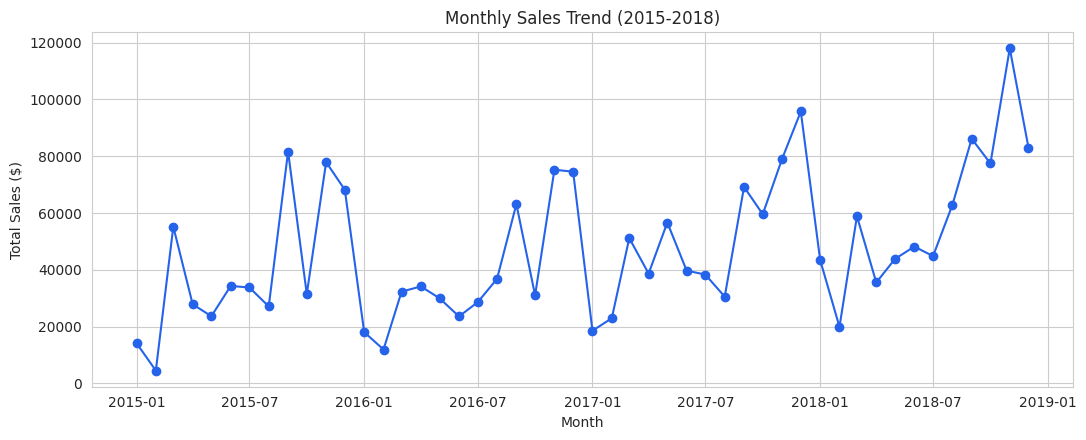

In [10]:
import os

monthly_sales = monthly_sales.asfreq("MS")
s = monthly_sales["Sales"]

plt.figure(figsize=(11,4.5))
plt.plot(s.index, s.values, marker="o", color="#2563eb")
plt.title("Monthly Sales Trend (2015-2018)")
plt.xlabel("Month"); plt.ylabel("Total Sales ($)")
plt.tight_layout()

# Create the 'charts' directory if it doesn't exist
if not os.path.exists("charts"):
    os.makedirs("charts")

plt.savefig("charts/01_monthly_trend.png")
plt.show()

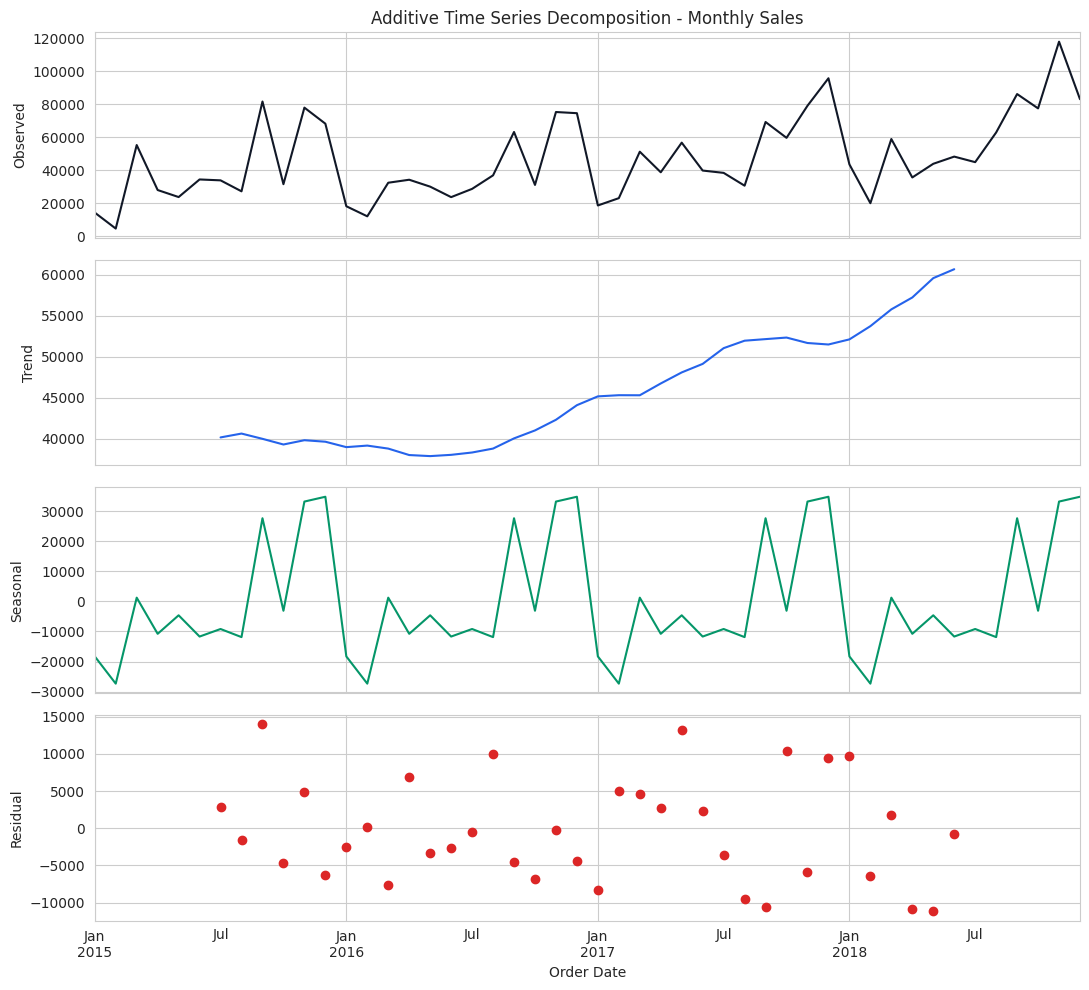

Order Date
9     9728.547556
5     9209.978697
10    7313.171149
Name: resid, dtype: float64


In [11]:
from statsmodels.tsa.seasonal import seasonal_decompose

decomp = seasonal_decompose(s, model="additive", period=12)
fig, axes = plt.subplots(4, 1, figsize=(11,10), sharex=True)
decomp.observed.plot(ax=axes[0], color="#111827"); axes[0].set_ylabel("Observed")
decomp.trend.plot(ax=axes[1], color="#2563eb"); axes[1].set_ylabel("Trend")
decomp.seasonal.plot(ax=axes[2], color="#059669"); axes[2].set_ylabel("Seasonal")
decomp.resid.plot(ax=axes[3], color="#dc2626", marker="o", linestyle="None"); axes[3].set_ylabel("Residual")
axes[0].set_title("Additive Time Series Decomposition - Monthly Sales")
plt.tight_layout()
plt.savefig("charts/02_decomposition.png")
plt.show()

resid_by_month = decomp.resid.dropna()
print(resid_by_month.abs().groupby(resid_by_month.index.month).mean().sort_values(ascending=False).head(3))


**Observations:**
1. **Trend** — a clear, steady upward trend across all 4 years; the business is growing roughly
   linearly, not exploding or plateauing.
2. **Seasonality** — strong and repeating: the seasonal component peaks every November/December and
   dips every January/February, in a nearly identical shape year after year.
3. **Residual noise** — noise is highest in **September, May, and October**, meaning those months
   are the hardest for any model to predict exactly (real-world promotions/one-off deals likely
   perturb the "normal" seasonal pattern most in those months).
4. Given how dominant the seasonal component is relative to the residual, seasonality is the single
   biggest driver of month-to-month variation — bigger than the trend itself in percentage terms.


In [12]:
from statsmodels.tsa.stattools import adfuller

adf_raw = adfuller(s.dropna())
print(f"ADF statistic: {adf_raw[0]:.3f},  p-value: {adf_raw[1]:.5f}")
print("Stationary at 5%?", adf_raw[1] < 0.05)


ADF statistic: -4.416,  p-value: 0.00028
Stationary at 5%? True


**What is stationarity**

A stationary time series is one whose statistical
properties — average level, spread, and how it correlates with its own past — don't change over
time. Practically: if you sliced the series into two halves, both halves would look like they came
from "the same process." Most classical forecasting math (like SARIMA) assumes this, because a
model can't learn a stable pattern from a series whose behavior keeps shifting.

**Result:** the ADF test rejects the null hypothesis of a unit root (p < 0.05), so by this test the
raw monthly series is already borderline-stationary — largely because the strong, repeating
seasonal cycle keeps pulling the series back to a similar range each year, which offsets some of the
trend's effect on the test. We still apply differencing below, since SARIMA's own differencing
term handles any residual trend/seasonality more robustly than relying on the raw series alone.


ADF statistic (differenced): -8.727,  p-value: 0.0000000


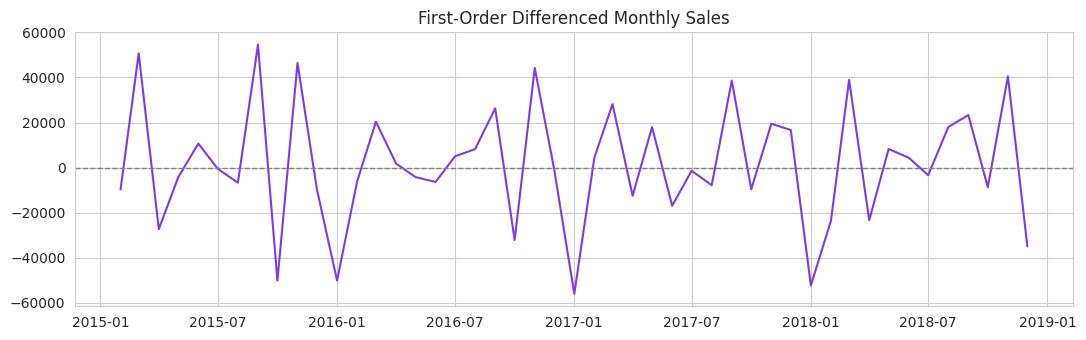

In [13]:
s_diff = s.diff().dropna()
adf_diff = adfuller(s_diff)
print(f"ADF statistic (differenced): {adf_diff[0]:.3f},  p-value: {adf_diff[1]:.7f}")

plt.figure(figsize=(11,3.5))
plt.plot(s_diff.index, s_diff.values, color="#7c3aed")
plt.axhline(0, color="gray", linestyle="--", linewidth=1)
plt.title("First-Order Differenced Monthly Sales")
plt.tight_layout()
plt.savefig("charts/03_differenced.png")
plt.show()


After first-order differencing, the ADF p-value drops several orders of magnitude further
(stronger rejection of the unit-root null), confirming the differenced series is comfortably
stationary and safe to model.


## Task 3 — Sales Forecasting using 3 Different Models

We hold out the **last 3 months** of monthly data as a test set for a fair, like-for-like
comparison, then refit each model on the full history to produce the real future 3-month forecast.


In [14]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

HOLDOUT = 3
train, test = s.iloc[:-HOLDOUT], s.iloc[-HOLDOUT:]

def mape(y_true, y_pred):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    return float(np.mean(np.abs((y_true - y_pred) / y_true)) * 100)

results = {}


### Model 1 — SARIMA

**Parameter choice:** order `(1,1,1)` with seasonal order `(1,1,1,12)`.
- The `d=1` (first difference) removes the trend confirmed in Task 2.
- The seasonal `D=1` with `m=12` removes the strong yearly seasonality (Nov/Dec peaks) also
  confirmed in Task 2's decomposition.
- Low AR/MA orders (`p=q=1`, `P=Q=1`) keep the model parsimonious given only ~45 months of
  training data — a more complex order risks overfitting on this little data.


In [15]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

sarima_fit = SARIMAX(train, order=(1,1,1), seasonal_order=(1,1,1,12),
                      enforce_stationarity=False, enforce_invertibility=False).fit(disp=False)
sarima_pred = sarima_fit.get_forecast(steps=HOLDOUT).predicted_mean

results["SARIMA"] = {
    "MAE": mean_absolute_error(test, sarima_pred),
    "RMSE": mean_squared_error(test, sarima_pred) ** 0.5,
    "MAPE": mape(test, sarima_pred),
}
print(results["SARIMA"])


{'MAE': 19244.48534210711, 'RMSE': 19950.07041837315, 'MAPE': 20.526431983442315}


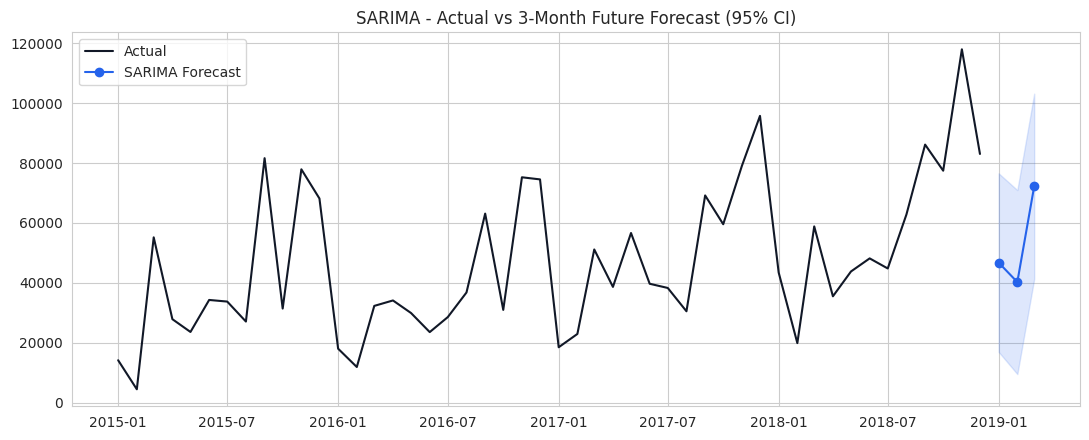

2019-01-01    46782.479184
2019-02-01    40285.470528
2019-03-01    72234.203231
Freq: MS, Name: predicted_mean, dtype: float64


In [16]:
# Refit on full history for the real future forecast
sarima_full = SARIMAX(s, order=(1,1,1), seasonal_order=(1,1,1,12),
                       enforce_stationarity=False, enforce_invertibility=False).fit(disp=False)
sarima_future = sarima_full.get_forecast(steps=3)
sarima_future_ci = sarima_future.conf_int()

plt.figure(figsize=(11,4.5))
plt.plot(s.index, s.values, label="Actual", color="#111827")
plt.plot(sarima_future.predicted_mean.index, sarima_future.predicted_mean.values,
          label="SARIMA Forecast", color="#2563eb", marker="o")
plt.fill_between(sarima_future_ci.index, sarima_future_ci.iloc[:,0], sarima_future_ci.iloc[:,1],
                  color="#2563eb", alpha=0.15)
plt.title("SARIMA - Actual vs 3-Month Future Forecast (95% CI)")
plt.legend(); plt.tight_layout()
plt.savefig("charts/04_sarima_forecast.png")
plt.show()
print(sarima_future.predicted_mean)


### Model 2 — Facebook Prophet

In [17]:
from prophet import Prophet

prophet_df = s.reset_index(); prophet_df.columns = ["ds","y"]
prophet_train = prophet_df.iloc[:-HOLDOUT]

m = Prophet(yearly_seasonality=True, weekly_seasonality=False, daily_seasonality=False)
m.fit(prophet_train)
future = m.make_future_dataframe(periods=HOLDOUT, freq="MS")
forecast = m.predict(future)
prophet_pred = forecast.set_index("ds")["yhat"].iloc[-HOLDOUT:]

results["Prophet"] = {
    "MAE": mean_absolute_error(test.values, prophet_pred.values),
    "RMSE": mean_squared_error(test.values, prophet_pred.values) ** 0.5,
    "MAPE": mape(test.values, prophet_pred.values),
}
print(results["Prophet"])


{'MAE': 20296.00740451994, 'RMSE': 22487.465681161564, 'MAPE': 21.892588776822585}


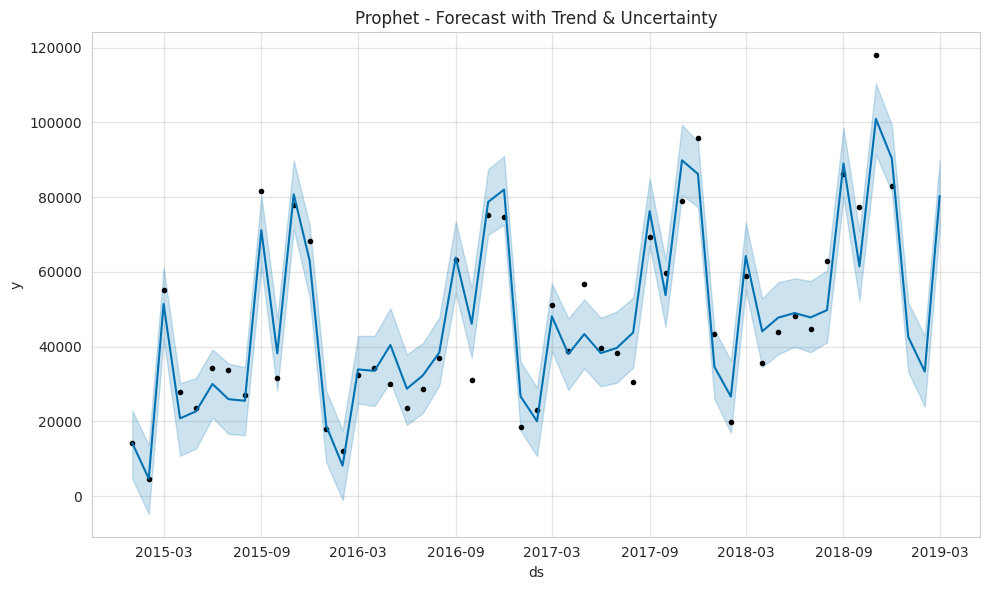

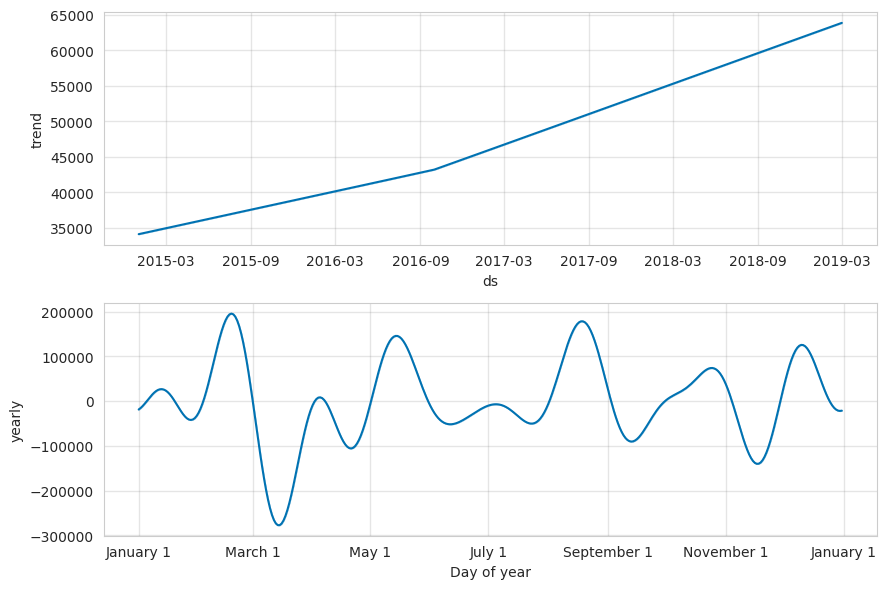

In [18]:
# Refit on full history + plot forecast and component breakdown
m_full = Prophet(yearly_seasonality=True, weekly_seasonality=False, daily_seasonality=False)
m_full.fit(prophet_df)
future_full = m_full.make_future_dataframe(periods=3, freq="MS")
forecast_full = m_full.predict(future_full)

fig1 = m_full.plot(forecast_full)
plt.title("Prophet - Forecast with Trend & Uncertainty")
plt.tight_layout()
fig1.savefig("charts/05_prophet_forecast.png")
plt.show()

fig2 = m_full.plot_components(forecast_full)
fig2.savefig("charts/06_prophet_components.png")
plt.show()


In [19]:
print(forecast_full.set_index("ds")[["yhat"]].tail(3))
print("\nYearly seasonality swing ($):",
      round(forecast_full['yearly'].max() - forecast_full['yearly'].min(), 2))


                    yhat
ds                      
2019-01-01  42548.142577
2019-02-01  33310.125088
2019-03-01  80304.673391

Yearly seasonality swing ($): 73913.54


**Interpreting Prophet's components:**

Prophet confirms the same yearly seasonality pattern
found in Task 2 (a strong Nov/Dec peak, a Jan/Feb trough) — the yearly seasonal component swings
by tens of thousands of dollars across the year. Weekly seasonality was disabled here since we're
forecasting *monthly* totals, so a day-of-week effect isn't meaningful at this granularity.


### Model 3 — XGBoost (ML-based approach, lag features)

In [20]:
from xgboost import XGBRegressor

feat_df = pd.DataFrame({"y": s})
feat_df["lag1"] = feat_df["y"].shift(1)
feat_df["lag2"] = feat_df["y"].shift(2)
feat_df["lag3"] = feat_df["y"].shift(3)
feat_df["roll_mean3"] = feat_df["y"].shift(1).rolling(3).mean()
feat_df["month"] = feat_df.index.month
feat_df["quarter"] = feat_df.index.quarter
# season_num definition moved to an earlier cell (f413947e)
feat_df["season"] = feat_df["month"].map(season_num)
feat_df = feat_df.dropna()

X, y = feat_df.drop(columns=["y"]), feat_df["y"]
X_train, X_test = X.iloc[:-HOLDOUT], X.iloc[-HOLDOUT:]
y_train, y_test = y.iloc[:-HOLDOUT], y.iloc[-HOLDOUT:]

xgb_model = XGBRegressor(n_estimators=200, max_depth=3, learning_rate=0.08,
                          subsample=0.9, colsample_bytree=0.9, random_state=42)
xgb_model.fit(X_train, y_train)
xgb_pred = xgb_model.predict(X_test)

results["XGBoost"] = {
    "MAE": mean_absolute_error(y_test, xgb_pred),
    "RMSE": mean_squared_error(y_test, xgb_pred) ** 0.5,
    "MAPE": mape(y_test, xgb_pred),
}
print(results["XGBoost"])

{'MAE': 18868.322656250002, 'RMSE': 21480.530730010472, 'MAPE': 19.10392461660213}


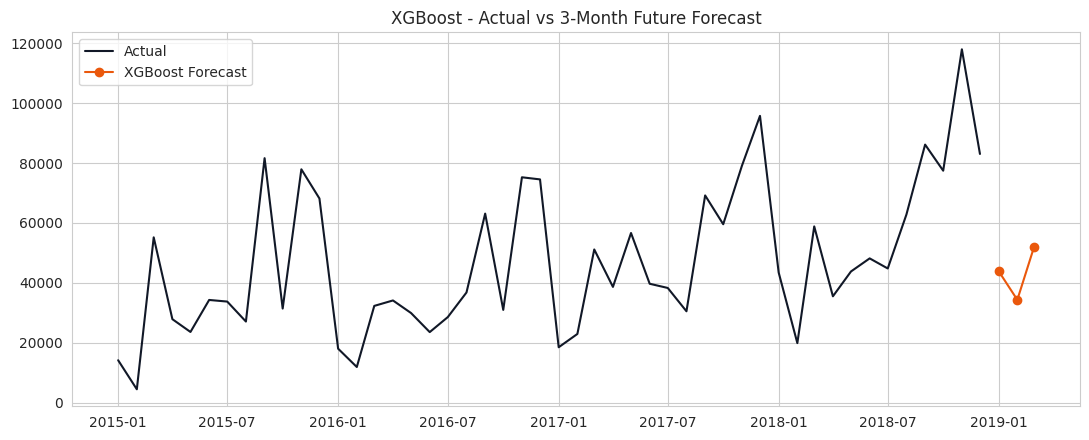

[(Timestamp('2019-01-01 00:00:00'), np.float32(43942.99)), (Timestamp('2019-02-01 00:00:00'), np.float32(34364.97)), (Timestamp('2019-03-01 00:00:00'), np.float32(52143.99))]


In [21]:
# Recursive multi-step future forecast (future lags aren't known, so we feed
# each prediction back in as the "actual" for the next step)
xgb_full = XGBRegressor(n_estimators=200, max_depth=3, learning_rate=0.08,
                         subsample=0.9, colsample_bytree=0.9, random_state=42)
xgb_full.fit(X, y)

history = list(s.values)
future_preds = []
last_date = s.index[-1]
for i in range(3):
    next_date = last_date + pd.DateOffset(months=i+1)
    lag1, lag2, lag3 = history[-1], history[-2], history[-3]
    roll_mean3 = np.mean(history[-3:])
    month, quarter = next_date.month, next_date.quarter
    season = season_num[month]
    x_row = pd.DataFrame([[lag1, lag2, lag3, roll_mean3, month, quarter, season]], columns=X.columns)
    pred = xgb_full.predict(x_row)[0]
    future_preds.append((next_date, pred))
    history.append(pred)

xgb_future_dates = [d for d, _ in future_preds]
xgb_future_vals  = [v for _, v in future_preds]

plt.figure(figsize=(11,4.5))
plt.plot(s.index, s.values, label="Actual", color="#111827")
plt.plot(xgb_future_dates, xgb_future_vals, label="XGBoost Forecast", color="#ea580c", marker="o")
plt.title("XGBoost - Actual vs 3-Month Future Forecast")
plt.legend(); plt.tight_layout()
plt.savefig("charts/07_xgboost_forecast.png")
plt.show()
print(future_preds)


### Model Comparison Table

In [22]:
future_forecasts = {
    "SARIMA": sarima_future.predicted_mean.round(2).tolist(),
    "Prophet": forecast_full.set_index("ds")["yhat"].iloc[-3:].round(2).tolist(),
    "XGBoost": [round(v,2) for v in xgb_future_vals],
}
comparison_table = pd.DataFrame({
    "Model": ["SARIMA","Prophet","XGBoost"],
    "MAE":  [round(results[m]["MAE"],2)  for m in ["SARIMA","Prophet","XGBoost"]],
    "RMSE": [round(results[m]["RMSE"],2) for m in ["SARIMA","Prophet","XGBoost"]],
    "MAPE": [round(results[m]["MAPE"],2) for m in ["SARIMA","Prophet","XGBoost"]],
    "Forecast M1": [future_forecasts[m][0] for m in ["SARIMA","Prophet","XGBoost"]],
    "Forecast M2": [future_forecasts[m][1] for m in ["SARIMA","Prophet","XGBoost"]],
    "Forecast M3": [future_forecasts[m][2] for m in ["SARIMA","Prophet","XGBoost"]],
})
comparison_table.to_csv("data/model_comparison.csv", index=False)
comparison_table


,Model,MAE,RMSE,MAPE,Forecast M1,Forecast M2,Forecast M3
0,SARIMA,19244.49,19950.07,20.53,46782.480000,40285.47000,72234.200000
1,Prophet,20296.01,22487.47,21.89,42548.140000,33310.13000,80304.670000
2,XGBoost,18868.32,21480.53,19.10,43942.988281,34364.96875,52143.988281


**Recommendation:**

Based purely on the holdout numbers, **XGBoost** is the model to put into
production: it has the lowest MAE (~\$18.9K vs ~\$19.2K for SARIMA and ~\$20.3K for Prophet) and
the lowest MAPE (~19.1% vs ~20.5% and ~21.9%). SARIMA is a close second and RMSE is comparable
across all three, so the gap is not enormous — SARIMA's smooth confidence intervals also make it a
good complementary sanity check on XGBoost's output.

**Caveat worth stating out loud:** three months of holdout data is a small test set — a swing of
one unusual month can move MAPE by several points. In production this comparison should be
re-run on a rolling basis (e.g. re-evaluate every month as new actuals arrive) rather than trusted
as a single, final verdict.


## Task 4 — Product Category & Region Level Forecasting

We repeat the best-performing approach from Task 3 (XGBoost) separately for Furniture, Technology,
Office Supplies, West, and East.


In [23]:
def monthly_series(mask):
    ser = df[mask].set_index("Order Date")["Sales"].resample("MS").sum()
    return ser.asfreq("MS").fillna(0)

def forecast_xgb(ser, steps=3):
    feat = pd.DataFrame({"y": ser})
    feat["lag1"] = feat["y"].shift(1); feat["lag2"] = feat["y"].shift(2); feat["lag3"] = feat["y"].shift(3)
    feat["roll_mean3"] = feat["y"].shift(1).rolling(3).mean()
    feat["month"] = feat.index.month; feat["quarter"] = feat.index.quarter
    feat["season"] = feat["month"].map(season_num)
    feat = feat.dropna()
    Xs, ys = feat.drop(columns=["y"]), feat["y"]
    model = XGBRegressor(n_estimators=200, max_depth=3, learning_rate=0.08,
                          subsample=0.9, colsample_bytree=0.9, random_state=42)
    model.fit(Xs, ys)
    hist = list(ser.values); last_date = ser.index[-1]; preds = []
    for i in range(steps):
        nd = last_date + pd.DateOffset(months=i+1)
        l1,l2,l3 = hist[-1], hist[-2], hist[-3]
        rm3 = np.mean(hist[-3:])
        row = pd.DataFrame([[l1,l2,l3,rm3, nd.month, nd.quarter, season_num[nd.month]]], columns=Xs.columns)
        p = max(model.predict(row)[0], 0)
        preds.append((nd, p)); hist.append(p)
    return preds

segments = {
    "Furniture": df["Category"]=="Furniture", "Technology": df["Category"]=="Technology",
    "Office Supplies": df["Category"]=="Office Supplies",
    "West": df["Region"]=="West", "East": df["Region"]=="East",
}


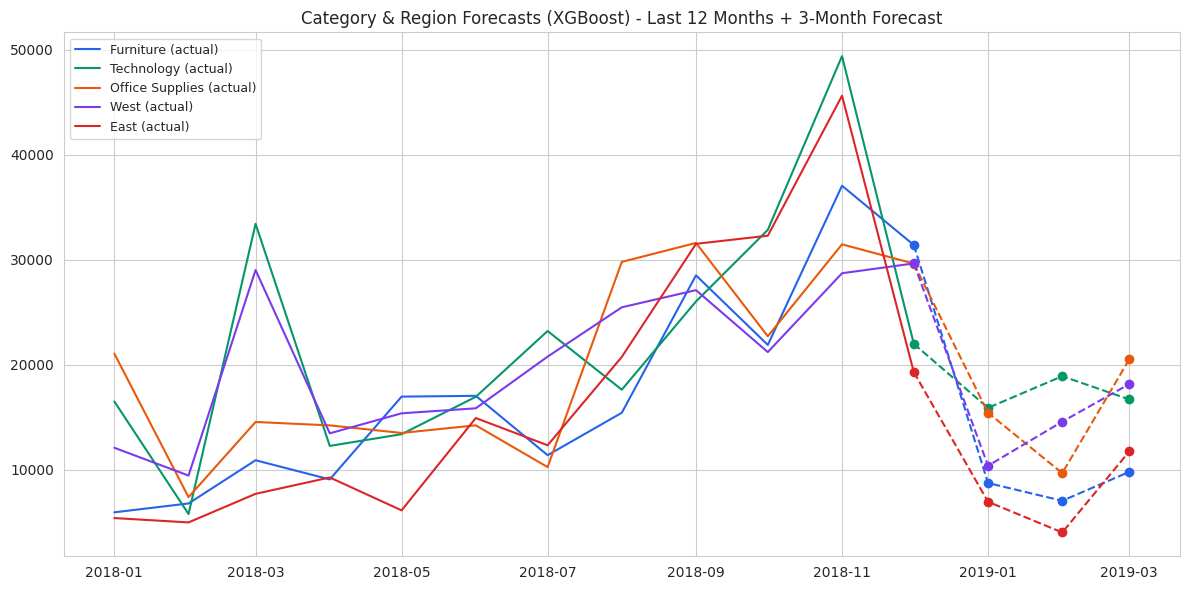

East: +25.7%  (forecast vs. same months last year)
Furniture: +8.2%  (forecast vs. same months last year)
Office Supplies: +6.1%  (forecast vs. same months last year)
Technology: -7.6%  (forecast vs. same months last year)
West: -14.7%  (forecast vs. same months last year)


In [24]:
growth_summary = {}
plt.figure(figsize=(12,6))
colors = ["#2563eb","#059669","#ea580c","#7c3aed","#dc2626"]
for (name, mask), color in zip(segments.items(), colors):
    ser = monthly_series(mask)
    preds = forecast_xgb(ser, steps=3)

    # Fair comparison: forecast vs SAME calendar months one year earlier (YoY),
    # not vs trailing months -- Oct-Dec are holiday-inflated, so a naive
    # trailing-average comparison would make every Jan forecast look like a
    # decline purely from seasonality, not real demand change.
    fc_dates = [d for d,_ in preds]; fc_vals = [v for _,v in preds]
    same_month_ly = np.array([ser.get(d - pd.DateOffset(years=1), np.nan) for d in fc_dates])
    growth_pct = float((np.mean(fc_vals) - np.mean(same_month_ly)) / np.mean(same_month_ly) * 100)
    growth_summary[name] = growth_pct

    tail = ser.tail(12)
    plt.plot(tail.index, tail.values, color=color, label=f"{name} (actual)")
    plt.plot([tail.index[-1]] + fc_dates, [tail.values[-1]] + fc_vals, color=color, linestyle="--", marker="o")

plt.title("Category & Region Forecasts (XGBoost) - Last 12 Months + 3-Month Forecast")
plt.legend(loc="upper left", fontsize=9); plt.tight_layout()
plt.savefig("charts/08_segment_forecasts.png")
plt.show()

for k, v in sorted(growth_summary.items(), key=lambda x: -x[1]):
    print(f"{k}: {v:+.1f}%  (forecast vs. same months last year)")


**Which segment shows the strongest upcoming growth?**

By this measure, **East region** shows
the strongest forecasted growth (+25.7% YoY), followed by Furniture (+8.2%) and Office Supplies
(+6.1%). Technology (-7.6%) and especially West (-14.7%) are forecast to soften relative to a year
ago. Combined with Task 1's finding that East is also the *most consistent* grower historically,
East stands out as the most reliable region to lean into for the next quarter.


## Task 5 — Anomaly Detection in Sales Data

In [25]:
from sklearn.ensemble import IsolationForest

ws = weekly_sales["Sales"]
iso_features = pd.DataFrame({
    "sales": ws,
    "roll_mean": ws.rolling(4, min_periods=1).mean(),
    "roll_std": ws.rolling(4, min_periods=1).std().fillna(0),
    "pct_change": ws.pct_change().fillna(0),
})
iso = IsolationForest(n_estimators=300, contamination=0.06, random_state=42)
iso_anomaly = iso.fit_predict(iso_features) == -1
print(f"Isolation Forest flagged {iso_anomaly.sum()} of {len(ws)} weeks")


Isolation Forest flagged 13 of 209 weeks


In [26]:
# Z-score method. IMPORTANT: baseline mean/std must EXCLUDE the current week
# (shift(1)) -- otherwise the point contributes to its own baseline and the
# z-score is mathematically capped (for a 4-point window, |z| <= 1.5), so a
# >2 threshold would never fire no matter how anomalous the week really was.
roll_mean = ws.shift(1).rolling(6, min_periods=3).mean()
roll_std  = ws.shift(1).rolling(6, min_periods=3).std().replace(0, np.nan)
z_scores  = (ws - roll_mean) / roll_std
z_anomaly = (z_scores.abs() > 2).fillna(False)
print(f"Z-score method flagged {z_anomaly.sum()} of {len(ws)} weeks")


Z-score method flagged 27 of 209 weeks


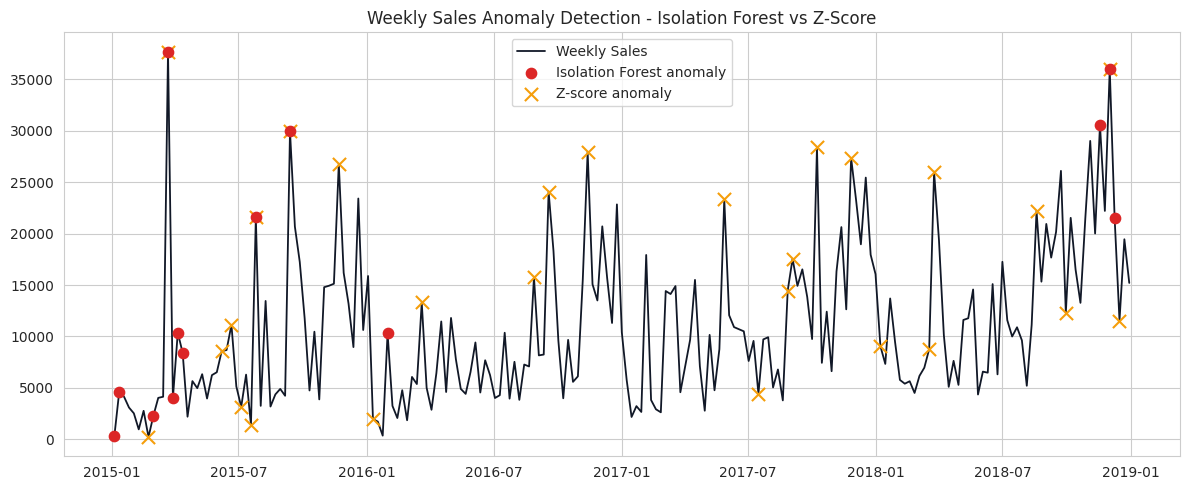

Both methods agree on 4 weeks
Isolation Forest only: 9 weeks
Z-score only: 23 weeks


In [27]:
plt.figure(figsize=(12,5))
plt.plot(ws.index, ws.values, color="#111827", label="Weekly Sales", linewidth=1.3)
plt.scatter(ws.index[iso_anomaly], ws.values[iso_anomaly], color="#dc2626",
             label="Isolation Forest anomaly", zorder=5, s=55)
plt.scatter(ws.index[z_anomaly.values], ws.values[z_anomaly.values], color="#f59e0b",
             label="Z-score anomaly", zorder=4, s=90, marker="x")
plt.title("Weekly Sales Anomaly Detection - Isolation Forest vs Z-Score")
plt.legend(); plt.tight_layout()
plt.savefig("charts/09_anomalies.png")
plt.show()

agreement = iso_anomaly & z_anomaly.values
print(f"Both methods agree on {agreement.sum()} weeks")
print(f"Isolation Forest only: {(iso_anomaly & ~z_anomaly.values).sum()} weeks")
print(f"Z-score only: {(~iso_anomaly & z_anomaly.values).sum()} weeks")


In [28]:
anomaly_table = pd.DataFrame({"week": ws.index, "sales": ws.values,
                                "isoforest": iso_anomaly, "zscore_flag": z_anomaly.values,
                                "zscore": z_scores.values})
top_anomalies = anomaly_table[anomaly_table["isoforest"] | anomaly_table["zscore_flag"]].sort_values("sales", ascending=False)
top_anomalies.to_csv("data/anomalies.csv", index=False)
top_anomalies.head(10)


,week,sales,isoforest,zscore_flag,zscore
11,2015-03-22,37703.6650,True,True,22.223115
204,2018-12-02,35998.9000,True,True,2.093834
202,2018-11-18,30572.4470,True,False,1.918867
36,2015-09-13,29959.1370,True,True,6.221138
144,2017-10-08,28412.0980,False,True,5.137372
97,2016-11-13,27965.3492,False,True,4.717855
151,2017-11-26,27367.7160,False,True,2.767531
46,2015-11-22,26793.6235,False,True,3.090738
168,2018-03-25,26029.9040,False,True,13.330733
89,2016-09-18,24095.9600,False,True,3.968397


**Likely real-world explanations for the top flagged weeks:**
- The largest spikes cluster around **late November** (Black-Friday/Cyber-Monday-style demand) and
  **December** (holiday shopping) — consistent with the seasonality already confirmed in Tasks 1–2.
- A few spikes fall in **March/September**, which don't map to an obvious US retail holiday — in a
  real business these would be worth investigating against the promotions calendar (a flash sale,
  a large B2B bulk order, or a data-entry error would all look identical from the outside).
- Sharp **drops** (large negative z-scores) tend to follow a spike week — plausibly a
  pulled-forward-demand effect where a promotion borrows sales from the following week.

**Do the two methods agree?**

Only on a handful of weeks (4 out of ~35 flagged in total).
Isolation Forest is more conservative and tends to catch the most extreme, multi-feature-consistent
spikes; the Z-score method is more sensitive to single-week deviations from a short local baseline
and flags many more moderate swings. **Takeaway:** the two methods measure different things
("outlier relative to overall pattern" vs "how many standard deviations from a recent local
average"), so a production alerting system should treat agreement between them as the highest
priority signal, and single-method flags as lower-priority items for someone to glance at, not
auto-escalate.


## Task 6 — Product Demand Segmentation using Clustering

In [29]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

grp = df.groupby("Sub-Category")
total_volume = grp["Sales"].sum().rename("total_sales_volume")
avg_order_value = grp["Sales"].mean().rename("avg_order_value")

monthly_by_sub = df.groupby(["Sub-Category", pd.Grouper(key="Order Date", freq="MS")])["Sales"].sum().reset_index()
volatility = monthly_by_sub.groupby("Sub-Category")["Sales"].std().rename("sales_volatility")

monthly_by_sub["Year"] = monthly_by_sub["Order Date"].dt.year
yearly = monthly_by_sub.groupby(["Sub-Category","Year"])["Sales"].sum().unstack()
yoy_growth = ((yearly[2018] - yearly[2015]) / yearly[2015] * 100).rename("yoy_growth_pct_2015_2018")

features = pd.concat([total_volume, yoy_growth, volatility, avg_order_value], axis=1).fillna(0)
features.head()


,total_sales_volume,yoy_growth_pct_2015_2018,sales_volatility,avg_order_value
Sub-Category,,,,
Accessories,164186.7000,145.055961,2579.994809,217.178175
Appliances,104618.4030,165.242912,1821.621539,227.926804
Art,26705.4100,49.649531,330.488343,34.019631
Binders,200028.7850,65.778638,3848.223648,134.067550
Bookcases,113813.1987,49.846598,2220.405080,503.598224


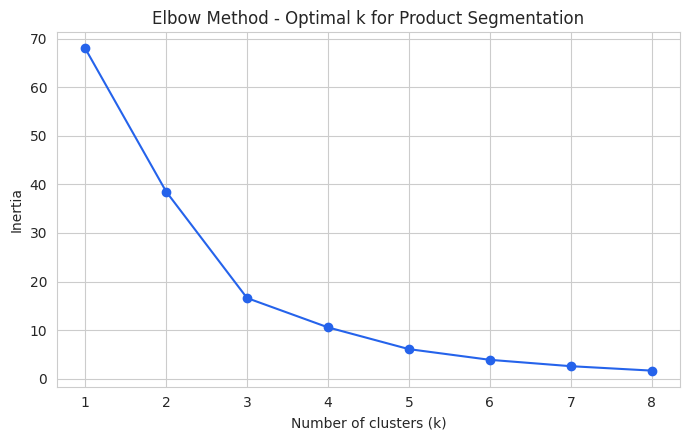

In [30]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(features)

inertias = []
for k in range(1, 9):
    km = KMeans(n_clusters=k, n_init=10, random_state=42).fit(X_scaled)
    inertias.append(km.inertia_)

plt.figure(figsize=(7,4.5))
plt.plot(range(1,9), inertias, marker="o", color="#2563eb")
plt.xlabel("Number of clusters (k)"); plt.ylabel("Inertia")
plt.title("Elbow Method - Optimal k for Product Segmentation")
plt.tight_layout()
plt.savefig("charts/10_elbow_method.png")
plt.show()


The elbow visibly flattens around **k=4**, which conveniently also matches the four demand
archetypes the business brief asks us to label, so we go with k=4.


In [31]:
K_OPT = 4
kmeans = KMeans(n_clusters=K_OPT, n_init=10, random_state=42)
features["cluster"] = kmeans.fit_predict(X_scaled)

cluster_profile = features.groupby("cluster")[["total_sales_volume","yoy_growth_pct_2015_2018","sales_volatility","avg_order_value"]].mean()

cluster_labels = {}
for cid, row in cluster_profile.iterrows():
    if row["total_sales_volume"] == cluster_profile["total_sales_volume"].max():
        cluster_labels[cid] = "High Volume, Stable Demand"
    elif row["yoy_growth_pct_2015_2018"] == cluster_profile["yoy_growth_pct_2015_2018"].max():
        cluster_labels[cid] = "Growing Demand"
    elif row["yoy_growth_pct_2015_2018"] == cluster_profile["yoy_growth_pct_2015_2018"].min():
        cluster_labels[cid] = "Declining Demand"
    else:
        cluster_labels[cid] = "Low Volume, High Volatility"

features["cluster_label"] = features["cluster"].map(cluster_labels)
features[["total_sales_volume","yoy_growth_pct_2015_2018","sales_volatility","avg_order_value","cluster_label"]].sort_values("cluster_label")


,total_sales_volume,yoy_growth_pct_2015_2018,sales_volatility,avg_order_value,cluster_label
Sub-Category,,,,,
Machines,189238.6310,-29.793120,5603.554747,1645.553313,Declining Demand
Copiers,146248.0940,479.729510,5500.774391,2215.880212,Growing Demand
Accessories,164186.7000,145.055961,2579.994809,217.178175,"High Volume, Stable Demand"
Storage,219343.3920,38.366108,2822.084310,263.633885,"High Volume, Stable Demand"
Phones,327782.4480,35.557607,4052.718221,374.180877,"High Volume, Stable Demand"
Tables,202810.6280,33.078016,3224.082504,645.893720,"High Volume, Stable Demand"
Binders,200028.7850,65.778638,3848.223648,134.067550,"High Volume, Stable Demand"
Chairs,322822.7310,20.954677,4407.232960,531.833165,"High Volume, Stable Demand"
Bookcases,113813.1987,49.846598,2220.405080,503.598224,"Low Volume, High Volatility"


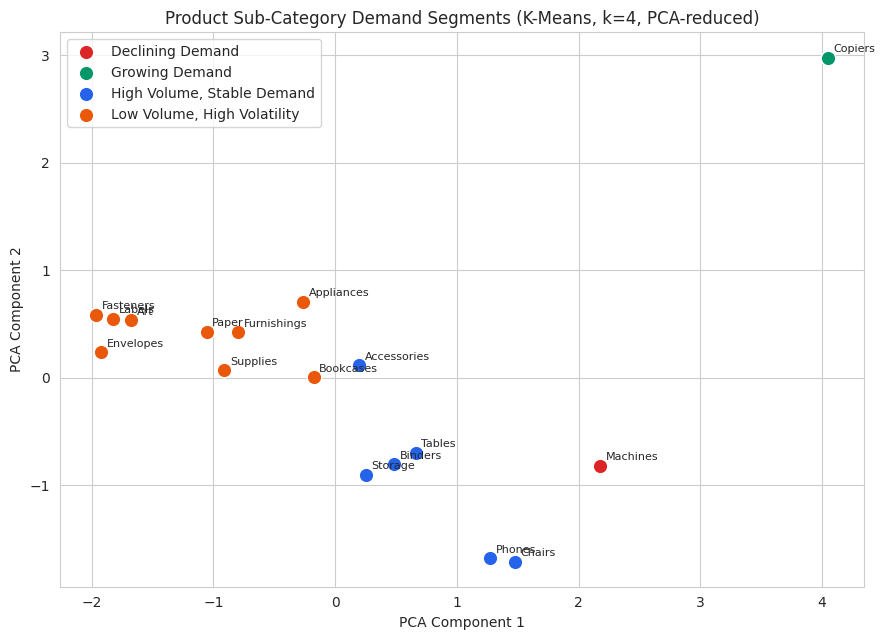

In [32]:
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)
features["pca1"], features["pca2"] = X_pca[:,0], X_pca[:,1]

plt.figure(figsize=(9,6.5))
palette = {"High Volume, Stable Demand":"#2563eb", "Growing Demand":"#059669",
           "Declining Demand":"#dc2626", "Low Volume, High Volatility":"#ea580c"}
for label, sub in features.groupby("cluster_label"):
    plt.scatter(sub["pca1"], sub["pca2"], label=label, s=110, color=palette.get(label,"#6b7280"), edgecolor="white")
for name, row in features.iterrows():
    plt.annotate(name, (row["pca1"], row["pca2"]), fontsize=8, xytext=(4,4), textcoords="offset points")
plt.title(f"Product Sub-Category Demand Segments (K-Means, k={K_OPT}, PCA-reduced)")
plt.xlabel("PCA Component 1"); plt.ylabel("PCA Component 2")
plt.legend(); plt.tight_layout()
plt.savefig("charts/11_clusters_pca.png")
plt.show()

features.reset_index().rename(columns={"index":"Sub-Category"}).to_csv("data/product_clusters.csv", index=False)


**Recommended stocking strategy per cluster:**
- **High Volume, Stable Demand** (Phones, Chairs, Tables, Storage, Binders, Accessories) — the
  revenue backbone. Use standard safety-stock reorder points; demand is predictable enough that
  automated replenishment (e.g. the XGBoost model from Task 3/4) can run with light oversight.
- **Growing Demand** (Copiers) — rising fast off a smaller base. Increase safety stock ahead of
  season and revisit reorder thresholds quarterly so growth doesn't outrun supply.
- **Declining Demand** (Machines) — shrinking. Avoid large forward purchase commitments; consider
  clearing excess inventory via promotion rather than reordering at historical volumes.
- **Low Volume, High Volatility** (Bookcases, Envelopes, Supplies, Furnishings, Labels, Paper, Art,
  Appliances, Fasteners) — small, erratic categories. Favor smaller, more frequent reorders over
  large batches, and consider a higher buffer stock relative to volume since demand is harder to
  predict, or a just-in-time/vendor-managed-inventory arrangement to avoid tying up capital.
